In [1]:
import pandas as pd
import numpy as np
import regex as re
import string
data = pd.read_csv(r"C:\Users\31760\Desktop\Inter DS\PBL2\intermediate-data-science-PBL2\reddit_dr.csv")
data.head()

,Title,Political Lean,Score,Id,Subreddit,URL,Num of Comments,Text,Date Created
0,"No matter who someone is, how they look like, ...",Liberal,1,t5fybt,socialism,https://v.redd.it/ng5fyl7hp2l81,0,NaN,1.646272e+09
1,Biden speech draws 38.2 million U.S. TV viewers,Liberal,6,t5fqdn,democrats,https://www.reuters.com/world/us/biden-speech-...,1,NaN,1.646271e+09
2,State of the union,Liberal,1,t5fj9a,DemocraticSocialism,https://www.reddit.com/r/DemocraticSocialism/c...,1,Who watched the state of the union last night ...,1.646270e+09
3,We Should Just Give Poor People Money,Liberal,7,t5f7n9,SocialDemocracy,https://youtu.be/a80kRjpubG0,3,NaN,1.646270e+09
4,Do it for the Dew,Liberal,6,t5es2c,democrats,https://i.redd.it/drmunn90f2l81.jpg,1,NaN,1.646268e+09


In [2]:

def clean_reddit_text(text):
    text = re.sub(r"http\S+|www\S+", "", text)       # remove URLs
    text = re.sub(r"@\w+", "", text)                 # remove mentions
    text = text.translate(str.maketrans("", "", string.punctuation))# remove punctuation
    text = re.sub(r"&[a-z]+;|&#x?\w+;", " ", text)
    text = re.sub(r"\[deleted\]|\[removed\]", " ", text)  
    text = re.sub(r"\s+", " ", text).strip()         # remove extra spaces
    return text

# Apply cleaning to the text
data["combined"] = (data["Title"].fillna("") + " " + data["Text"].fillna("")).apply(clean_reddit_text)
condition = data["Political Lean"].str.strip().str.lower() == "liberal"
data["isLiberal"] = np.where(condition, 1, 0)
x = data["combined"]
y = data["isLiberal"]

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0, stratify=y)

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words="english")   # 
X_train_tfidf = vectorizer.fit_transform(X_train)    # 
X_test_tfidf  = vectorizer.transform(X_test)         # 

In [5]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_tfidf, y_train)
y_pred = logreg.predict(X_test_tfidf)
feature_names = vectorizer.get_feature_names_out()
coefs = logreg.coef_[0]
top_lib = np.argsort(coefs)[-15:]      # most Liberal
top_con = np.argsort(coefs)[:15]       # most Conservative
print("Liberal:", feature_names[top_lib])
print("Conservative:", feature_names[top_con])

Liberal: ['class' 'coup' 'statement' 'feminism' 'dsa' 'election' 'party' 'feminist'
 'opinion' 'plan' 'solidarity' 'democratic' 'cuba' 'workers' 'women']
Conservative: ['libertarian' 'desantis' 'libertarians' 'anarchocapitalism' 'capitalism'
 'trudeau' 'putin' 'ancap' 'property' 'ukraine' 'bitcoin' 'government'
 'durham' 'invasion' 'cpac']


In [6]:
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(accuracy_score(y_test, y_pred)))
print(classification_report(y_test, y_pred, target_names=["Conservative", "Liberal"]))

Accuracy of logistic regression classifier on test set: 0.76
              precision    recall  f1-score   support

Conservative       0.78      0.45      0.57      1361
     Liberal       0.76      0.93      0.84      2496

    accuracy                           0.76      3857
   macro avg       0.77      0.69      0.71      3857
weighted avg       0.77      0.76      0.74      3857



In [7]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_tfidf, y_train)             
y_pred = model.predict(X_test_tfidf)
feature_names = vectorizer.get_feature_names_out()
coefs = model.coef_[0]
top_lib = np.argsort(coefs)[-15:]      # most Liberal
top_con = np.argsort(coefs)[:15]       # most Conservative
print("Liberal:", feature_names[top_lib])
print("Conservative:", feature_names[top_con])
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(accuracy_score(y_test, y_pred)))
print(classification_report(y_test, y_pred, target_names=["Conservative", "Liberal"]))

Liberal: ['coup' 'statement' 'class' 'feminism' 'dsa' 'election' 'feminist' 'plan'
 'opinion' 'party' 'solidarity' 'democratic' 'cuba' 'workers' 'women']
Conservative: ['libertarian' 'desantis' 'capitalism' 'putin' 'libertarians'
 'anarchocapitalism' 'trudeau' 'ukraine' 'government' 'property' 'ancap'
 'inflation' 'cpac' 'invasion' 'bitcoin']
Accuracy of logistic regression classifier on test set: 0.76
              precision    recall  f1-score   support

Conservative       0.66      0.68      0.67      1361
     Liberal       0.82      0.81      0.81      2496

    accuracy                           0.76      3857
   macro avg       0.74      0.74      0.74      3857
weighted avg       0.76      0.76      0.76      3857



In [8]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom = ['libertarian', 'anarchocapitalism', 'libertarians', 'ancap', 'cpac', 'dsa']
combined_stop = list(ENGLISH_STOP_WORDS.union(custom))

vectorizer = TfidfVectorizer(ngram_range=(1,2), stop_words=combined_stop, max_features=20000)
X_train_tfidf_f = vectorizer.fit_transform(X_train)    # 
X_test_tfidf_f  = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train_tfidf_f, y_train)             
y_pred_f = model.predict(X_test_tfidf_f)
feature_names_f = vectorizer.get_feature_names_out()
coefs_f = model.coef_[0]
top_lib_f = np.argsort(coefs_f)[-15:]      # most Liberal
top_con_f = np.argsort(coefs_f)[:15]       # most Conservative
print("Liberal:", feature_names_f[top_lib_f])
print("Conservative:", feature_names_f[top_con_f])
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(accuracy_score(y_test, y_pred_f)))
print(classification_report(y_test, y_pred_f, target_names=["Conservative", "Liberal"]))


Liberal: ['democracy' 'coup' 'infrastructure' 'class' 'feminism' 'solidarity'
 'plan' 'democratic' 'opinion' 'election' 'party' 'feminist' 'cuba'
 'workers' 'women']
Conservative: ['desantis' 'putin' 'capitalism' 'ukraine' 'government' 'trudeau'
 'bitcoin' 'inflation' 'property' 'poll' 'russia' 'durham' 'canadian'
 'libertarianism' 'invasion']
Accuracy of logistic regression classifier on test set: 0.74
              precision    recall  f1-score   support

Conservative       0.63      0.66      0.64      1361
     Liberal       0.81      0.79      0.80      2496

    accuracy                           0.74      3857
   macro avg       0.72      0.72      0.72      3857
weighted avg       0.75      0.74      0.74      3857



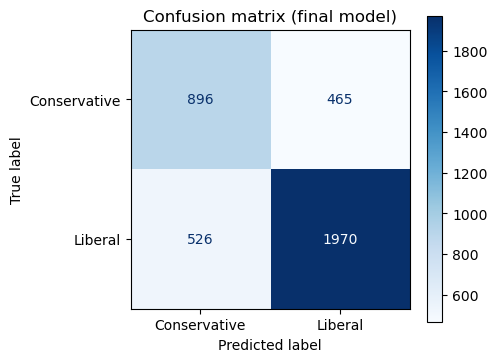

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_f,
    display_labels=["Conservative", "Liberal"],
    cmap="Blues", ax=ax
)
ax.set_title("Confusion matrix (final model)")
plt.tight_layout(); plt.savefig("fig2_confusion.png", dpi=150); plt.show()

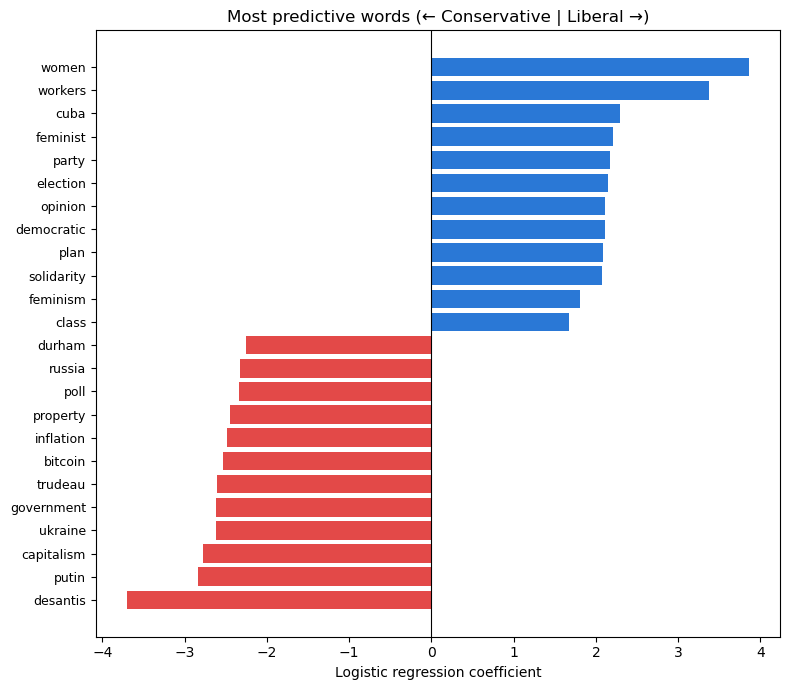

In [10]:
import numpy as np
import matplotlib.pyplot as plt

coefs_f = model.coef_[0]
names = vectorizer.get_feature_names_out()

n = 12
top_lib_idx = np.argsort(coefs_f)[-n:]
top_con_idx = np.argsort(coefs_f)[:n]
idx = np.concatenate([top_con_idx, top_lib_idx])
vals = coefs_f[idx]
labels = names[idx]
colors = ["#e34948" if v < 0 else "#2a78d6" for v in vals]   # 红=保守 蓝=自由

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(range(len(vals)), vals, color=colors)
ax.set_yticks(range(len(vals))); ax.set_yticklabels(labels, fontsize=9)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Logistic regression coefficient")
ax.set_title("Most predictive words (← Conservative | Liberal →)")
plt.tight_layout(); plt.savefig("fig3_coefs.png", dpi=150); plt.show()

C:\Users\31760\AppData\Local\Temp\ipykernel_28360\1366576737.py:27: UserWarning: Glyph 21435 (\N{CJK UNIFIED IDEOGRAPH-53BB}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.savefig("fig1_iterations.png", dpi=150); plt.show()
c:\Users\31760\miniconda3\envs\inter-ds\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21435 (\N{CJK UNIFIED IDEOGRAPH-53BB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


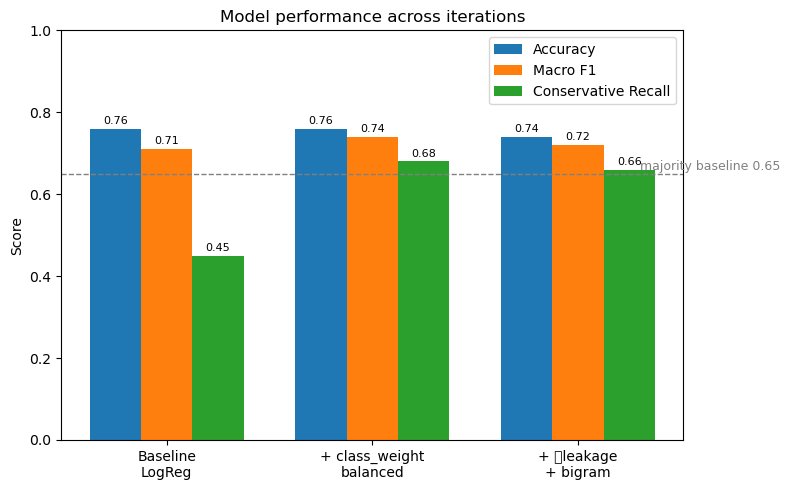

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

stages = ["Baseline\nLogReg", "+ class_weight\nbalanced", "+ 去leakage\n+ bigram"]
accuracy = [0.76, 0.76, 0.74]
macro_f1 = [0.71, 0.74, 0.72]
con_recall = [0.45, 0.68, 0.66]   

x = np.arange(len(stages))
w = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w, accuracy,   w, label="Accuracy")
ax.bar(x,     macro_f1,   w, label="Macro F1")
ax.bar(x + w, con_recall, w, label="Conservative Recall")

ax.set_xticks(x); ax.set_xticklabels(stages)
ax.set_ylabel("Score"); ax.set_ylim(0, 1)
ax.set_title("Model performance across iterations")
ax.legend()
ax.axhline(0.65, ls="--", color="gray", lw=1)  
ax.text(2.3, 0.66, "majority baseline 0.65", color="gray", fontsize=9)

for bars in ax.containers:
    ax.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)

plt.tight_layout(); plt.savefig("fig1_iterations.png", dpi=150); plt.show()